In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Nat_Gas.csv")

In [ ]:
print(df.head())

      Dates  Prices
0  10/31/20    10.1
1  11/30/20    10.3
2  12/31/20    11.0
3   1/31/21    10.9
4   2/28/21    10.9


In [ ]:
print(df.dtypes)

Dates      object
Prices    float64
dtype: object


In [ ]:
df['Dates'] = pd.to_datetime(df['Dates'])

/tmp/ipykernel_1098/2452315616.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


In [ ]:
df['Prices'] = df['Prices'].astype(float)

In [ ]:
df = df.sort_values('Dates').reset_index(drop=True)

In [ ]:
print(df.head())

       Dates  Prices
0 2020-10-31    10.1
1 2020-11-30    10.3
2 2020-12-31    11.0
3 2021-01-31    10.9
4 2021-02-28    10.9


In [ ]:
print(df.dtypes)

Dates     datetime64[ns]
Prices           float64
dtype: object


In [ ]:
print(f"\nDate range: {df['Dates'].min()} → {df['Dates'].max()}")


Date range: 2020-10-31 00:00:00 → 2024-09-30 00:00:00


In [ ]:
print(f"Total rows: {len(df)}")

Total rows: 48


In [ ]:
import matplotlib.pyplot as plt

/tmp/ipykernel_1098/3427686737.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


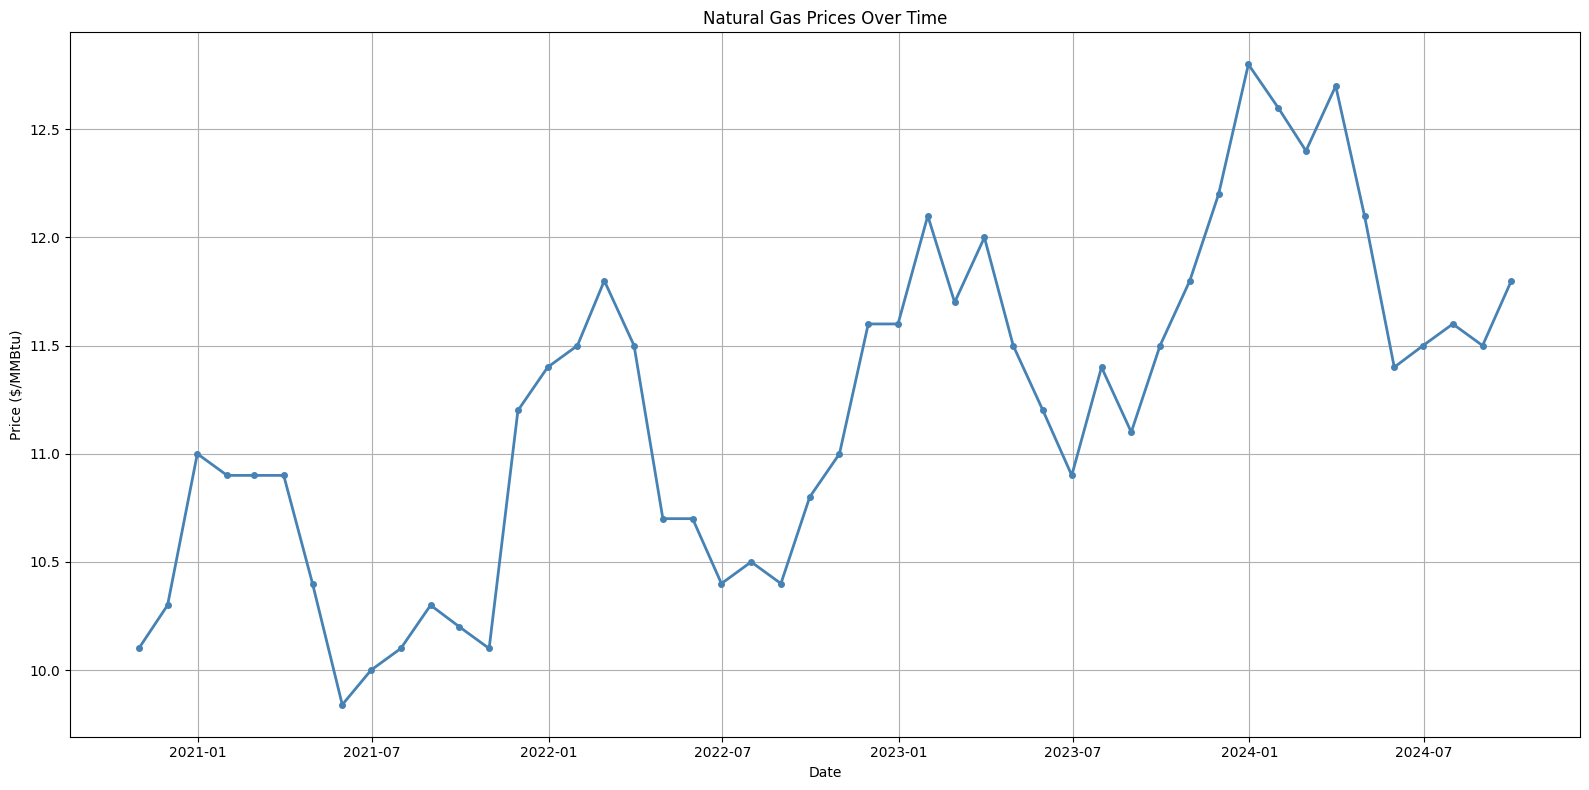

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Nat_Gas.csv")
df['Dates'] = pd.to_datetime(df['Dates'])
df['Prices'] = df['Prices'].astype(float)
df = df.sort_values('Dates').reset_index(drop=True)

plt.figure(figsize=(16, 8))
plt.plot(df['Dates'], df['Prices'], marker='o', color='steelblue', linewidth=2, markersize=4)
plt.title("Natural Gas Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price ($/MMBtu)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.interpolate import CubicSpline


In [ ]:
epoch = pd.Timestamp("1970-01-01")

In [ ]:
x =(df['Dates'] - epoch).dt.days.values.astype(float)

In [ ]:
y = df['Prices'].values.astype(float)

In [ ]:
spline = CubicSpline(x,y, extrapolate=True)

In [ ]:
def estimate_price(date_input):
  date_input = pd.to_datetime(date_input)
  x_query = (date_input - epoch).days
  price =float(spline(x_query))
  return round(price,4)

In [ ]:
print(estimate_price("2022-05-04"))#historical date
print(estimate_price("2022-03-15"))#future date

10.6618
11.7721


In [ ]:
future_end = pd.Timestamp("2025-09-30")
all_dates = pd.date_range(start=df['Dates'].min(), end=future_end, freq='D')

In [ ]:
x_all = (all_dates - epoch).days.values.astype(float)
y_all = spline(x_all)

In [ ]:
last_date = df['Dates'].max()
hist_mask = all_dates <= last_date
future_mask = all_dates >= last_date

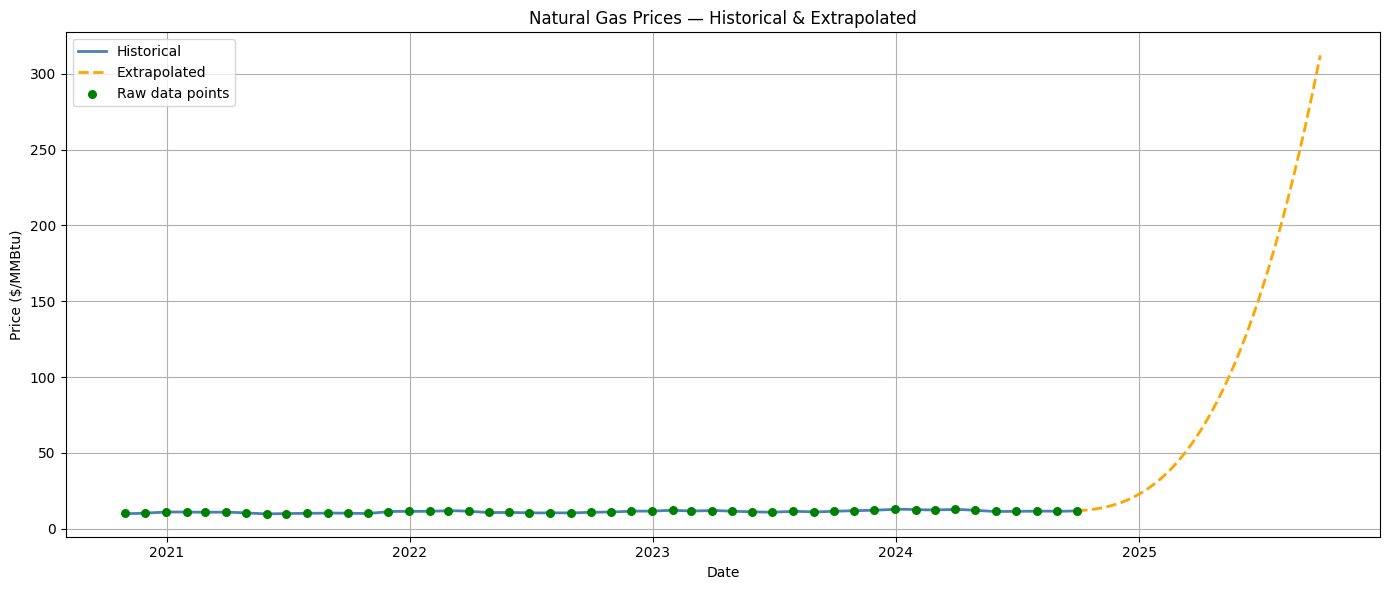

In [ ]:
plt.figure(figsize=(14, 6))


plt.plot(all_dates[hist_mask], y_all[hist_mask],
         color='steelblue', linewidth=2, label='Historical')


plt.plot(all_dates[future_mask], y_all[future_mask],
         color='orange', linewidth=2, linestyle='--', label='Extrapolated')


plt.scatter(df['Dates'], df['Prices'],
            color='green', s=30, zorder=5, label='Raw data points')

plt.title("Natural Gas Prices — Historical & Extrapolated")
plt.xlabel("Date")
plt.ylabel("Price ($/MMBtu)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()